# Лабораторная работа №3

**Студент:** Тавуз Мохамад  
**Группа:** ИУ5И-22М  
**Вариант:** 2

**Тема:** Методы многомерного поиска  


In [ ]:
# Импорт необходимых библиотек для выполнения лабораторной работы

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from scipy.optimize import minimize_scalar

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
# Задание параметров варианта и определение тестовой функции Розенброка

a = 150
b = 2
f0 = 100
n = 3

def rosenbrock_function(x):
    x = np.array(x, dtype=float)
    value = 0
    for i in range(n - 1):
        value += a * (x[i + 1] - x[i] ** 2) ** 2 + b * (x[i] - 1) ** 2
    return value + f0

x_star_theoretical = np.ones(n)
f_star_theoretical = rosenbrock_function(x_star_theoretical)

print("Variant:", 2)
print("a =", a)
print("b =", b)
print("f0 =", f0)
print("n =", n)
print("Theoretical minimum point:", x_star_theoretical)
print("Function value at theoretical minimum:", f_star_theoretical)

Variant: 2
a = 150
b = 2
f0 = 100
n = 3
Theoretical minimum point: [1. 1. 1.]
Function value at theoretical minimum: 100.0


In [ ]:
# Определение градиента функции Розенброка и проверка в точке минимума

def rosenbrock_gradient(x):
    x = np.array(x, dtype=float)
    grad = np.zeros_like(x)

    for i in range(n - 1):
        grad[i] += -4 * a * x[i] * (x[i + 1] - x[i] ** 2) + 2 * b * (x[i] - 1)
        grad[i + 1] += 2 * a * (x[i + 1] - x[i] ** 2)

    return grad

gradient_at_minimum = rosenbrock_gradient(x_star_theoretical)
gradient_norm_at_minimum = np.linalg.norm(gradient_at_minimum)

print("Gradient at theoretical minimum:", gradient_at_minimum)
print("Gradient norm at theoretical minimum:", gradient_norm_at_minimum)

Gradient at theoretical minimum: [0. 0. 0.]
Gradient norm at theoretical minimum: 0.0


In [ ]:
# Задание общих параметров алгоритмов и функции одномерного поиска

x0 = np.array([-1.2, 1.0, 0.5])

epsilon = 1e-6
epsilon_x = 1e-8
epsilon_f = 1e-10
max_iter = 1000

def line_search(f, x, d):
    result = minimize_scalar(
        lambda alpha: f(x + alpha * d),
        bounds=(0, 0.01),
        method='bounded',
        options={'xatol': 1e-10}
    )
    return result.x

print("Initial point:", x0)
print("Function value at initial point:", rosenbrock_function(x0))
print("Gradient norm at initial point:", np.linalg.norm(rosenbrock_gradient(x0)))
print("epsilon =", epsilon)
print("epsilon_x =", epsilon_x)
print("epsilon_f =", epsilon_f)
print("max_iter =", max_iter)

Initial point: [-1.2  1.   0.5]
Function value at initial point: 176.22
Gradient norm at initial point: 395.9032204971311
epsilon = 1e-06
epsilon_x = 1e-08
epsilon_f = 1e-10
max_iter = 1000


In [ ]:
# Реализация метода сопряженных градиентов Флетчера-Ривза с перезапуском направления

def fletcher_reeves(f, grad_f, x0, epsilon=1e-6, max_iter=1000):
    start_time = time.time()

    x = np.array(x0, dtype=float)
    grad = grad_f(x)
    d = -grad

    history = {
        "x": [x.copy()],
        "f": [f(x)],
        "grad_norm": [np.linalg.norm(grad)]
    }

    for k in range(max_iter):
        grad_norm = np.linalg.norm(grad)

        if grad_norm < epsilon:
            break

        if np.dot(grad, d) >= 0:
            d = -grad

        alpha = line_search(f, x, d)
        x_new = x + alpha * d
        grad_new = grad_f(x_new)

        beta = np.dot(grad_new, grad_new) / max(np.dot(grad, grad), 1e-20)

        if (k + 1) % n == 0:
            beta = 0

        d = -grad_new + beta * d

        history["x"].append(x_new.copy())
        history["f"].append(f(x_new))
        history["grad_norm"].append(np.linalg.norm(grad_new))

        if np.linalg.norm(x_new - x) < epsilon_x and abs(f(x_new) - f(x)) < epsilon_f:
            x = x_new
            grad = grad_new
            break

        x = x_new
        grad = grad_new

    execution_time = time.time() - start_time

    return {
        "method": "Fletcher-Reeves",
        "x_min": x,
        "f_min": f(x),
        "iterations": len(history["f"]) - 1,
        "grad_norm": np.linalg.norm(grad_f(x)),
        "time": execution_time,
        "history": history
    }

fr_result = fletcher_reeves(rosenbrock_function, rosenbrock_gradient, x0, epsilon, max_iter)

print("Method:", fr_result["method"])
print("Found minimum point:", fr_result["x_min"])
print("Function value:", fr_result["f_min"])
print("Iterations:", fr_result["iterations"])
print("Gradient norm:", fr_result["grad_norm"])
print("Execution time:", fr_result["time"])

Method: Fletcher-Reeves
Found minimum point: [0.99999852 0.99999703 0.99999405]
Function value: 100.00000000002201
Iterations: 661
Gradient norm: 8.377764176818737e-06
Execution time: 0.3449580669403076


In [ ]:
# Реализация метода сопряженных градиентов Полака-Рибьера с перезапуском направления

def polak_ribiere(f, grad_f, x0, epsilon=1e-6, max_iter=1000):
    start_time = time.time()

    x = np.array(x0, dtype=float)
    grad = grad_f(x)
    d = -grad

    history = {
        "x": [x.copy()],
        "f": [f(x)],
        "grad_norm": [np.linalg.norm(grad)]
    }

    for k in range(max_iter):
        grad_norm = np.linalg.norm(grad)

        if grad_norm < epsilon:
            break

        if np.dot(grad, d) >= 0:
            d = -grad

        alpha = line_search(f, x, d)
        x_new = x + alpha * d
        grad_new = grad_f(x_new)

        y = grad_new - grad
        beta = np.dot(grad_new, y) / max(np.dot(grad, grad), 1e-20)
        beta = max(beta, 0)

        if (k + 1) % n == 0:
            beta = 0

        d = -grad_new + beta * d

        history["x"].append(x_new.copy())
        history["f"].append(f(x_new))
        history["grad_norm"].append(np.linalg.norm(grad_new))

        if np.linalg.norm(x_new - x) < epsilon_x and abs(f(x_new) - f(x)) < epsilon_f:
            x = x_new
            grad = grad_new
            break

        x = x_new
        grad = grad_new

    execution_time = time.time() - start_time

    return {
        "method": "Polak-Ribiere",
        "x_min": x,
        "f_min": f(x),
        "iterations": len(history["f"]) - 1,
        "grad_norm": np.linalg.norm(grad_f(x)),
        "time": execution_time,
        "history": history
    }

pr_result = polak_ribiere(rosenbrock_function, rosenbrock_gradient, x0, epsilon, max_iter)

print("Method:", pr_result["method"])
print("Found minimum point:", pr_result["x_min"])
print("Function value:", pr_result["f_min"])
print("Iterations:", pr_result["iterations"])
print("Gradient norm:", pr_result["grad_norm"])
print("Execution time:", pr_result["time"])

Method: Polak-Ribiere
Found minimum point: [0.99999911 0.99999822 0.99999642]
Function value: 100.00000000000796
Iterations: 314
Gradient norm: 3.908735100114691e-06
Execution time: 0.1497941017150879


In [ ]:
# Определение одномерного поиска для квазиньютоновских методов

def line_search_quasi_newton(f, x, d):
    result = minimize_scalar(
        lambda alpha: f(x + alpha * d),
        bounds=(0, 1),
        method='bounded',
        options={'xatol': 1e-10}
    )
    return result.x

print("Line search for quasi-Newton methods is defined")

Line search for quasi-Newton methods is defined


In [ ]:
# Реализация квазиньютоновского метода Девидона-Флетчера-Пауэлла

def dfp_method(f, grad_f, x0, epsilon=1e-6, max_iter=1000):
    start_time = time.time()

    x = np.array(x0, dtype=float)
    H = np.eye(len(x))
    grad = grad_f(x)

    history = {
        "x": [x.copy()],
        "f": [f(x)],
        "grad_norm": [np.linalg.norm(grad)]
    }

    for k in range(max_iter):
        grad_norm = np.linalg.norm(grad)

        if grad_norm < epsilon:
            break

        d = -H @ grad

        if np.dot(grad, d) >= 0:
            H = np.eye(len(x))
            d = -grad

        alpha = line_search_quasi_newton(f, x, d)
        x_new = x + alpha * d
        grad_new = grad_f(x_new)

        s = x_new - x
        y = grad_new - grad

        sy = np.dot(s, y)
        Hy = H @ y
        yHy = np.dot(y, Hy)

        if sy > 1e-12 and yHy > 1e-12:
            H = H + np.outer(s, s) / sy - np.outer(Hy, Hy) / yHy
        else:
            H = np.eye(len(x))

        history["x"].append(x_new.copy())
        history["f"].append(f(x_new))
        history["grad_norm"].append(np.linalg.norm(grad_new))

        if np.linalg.norm(x_new - x) < epsilon_x and abs(f(x_new) - f(x)) < epsilon_f:
            x = x_new
            grad = grad_new
            break

        x = x_new
        grad = grad_new

    execution_time = time.time() - start_time

    return {
        "method": "DFP",
        "x_min": x,
        "f_min": f(x),
        "iterations": len(history["f"]) - 1,
        "grad_norm": np.linalg.norm(grad_f(x)),
        "time": execution_time,
        "history": history
    }

dfp_result = dfp_method(rosenbrock_function, rosenbrock_gradient, x0, epsilon, max_iter)

print("Method:", dfp_result["method"])
print("Found minimum point:", dfp_result["x_min"])
print("Function value:", dfp_result["f_min"])
print("Iterations:", dfp_result["iterations"])
print("Gradient norm:", dfp_result["grad_norm"])
print("Execution time:", dfp_result["time"])

Method: DFP
Found minimum point: [1.         1.00000001 1.00000003]
Function value: 100.0
Iterations: 44
Gradient norm: 2.4293243339881603e-06
Execution time: 0.0348515510559082


In [ ]:
# Реализация квазиньютоновского метода BFGS

def bfgs_method(f, grad_f, x0, epsilon=1e-6, max_iter=1000):
    start_time = time.time()

    x = np.array(x0, dtype=float)
    H = np.eye(len(x))
    grad = grad_f(x)

    history = {
        "x": [x.copy()],
        "f": [f(x)],
        "grad_norm": [np.linalg.norm(grad)]
    }

    for k in range(max_iter):
        grad_norm = np.linalg.norm(grad)

        if grad_norm < epsilon:
            break

        d = -H @ grad

        if np.dot(grad, d) >= 0:
            H = np.eye(len(x))
            d = -grad

        alpha = line_search_quasi_newton(f, x, d)
        x_new = x + alpha * d
        grad_new = grad_f(x_new)

        s = x_new - x
        y = grad_new - grad
        sy = np.dot(s, y)

        if sy > 1e-12:
            rho = 1.0 / sy
            I = np.eye(len(x))
            H = (I - rho * np.outer(s, y)) @ H @ (I - rho * np.outer(y, s)) + rho * np.outer(s, s)
        else:
            H = np.eye(len(x))

        history["x"].append(x_new.copy())
        history["f"].append(f(x_new))
        history["grad_norm"].append(np.linalg.norm(grad_new))

        if np.linalg.norm(x_new - x) < epsilon_x and abs(f(x_new) - f(x)) < epsilon_f:
            x = x_new
            grad = grad_new
            break

        x = x_new
        grad = grad_new

    execution_time = time.time() - start_time

    return {
        "method": "BFGS",
        "x_min": x,
        "f_min": f(x),
        "iterations": len(history["f"]) - 1,
        "grad_norm": np.linalg.norm(grad_f(x)),
        "time": execution_time,
        "history": history
    }

bfgs_result = bfgs_method(rosenbrock_function, rosenbrock_gradient, x0, epsilon, max_iter)

print("Method:", bfgs_result["method"])
print("Found minimum point:", bfgs_result["x_min"])
print("Function value:", bfgs_result["f_min"])
print("Iterations:", bfgs_result["iterations"])
print("Gradient norm:", bfgs_result["grad_norm"])
print("Execution time:", bfgs_result["time"])

Method: BFGS
Found minimum point: [1. 1. 1.]
Function value: 100.0
Iterations: 38
Gradient norm: 2.6691543704683736e-10
Execution time: 0.02639007568359375


In [ ]:
# Реализация квазиньютоновского метода L-BFGS с ограниченной памятью

def lbfgs_method(f, grad_f, x0, epsilon=1e-6, max_iter=1000, m=5):
    start_time = time.time()

    x = np.array(x0, dtype=float)
    grad = grad_f(x)

    s_list = []
    y_list = []

    history = {
        "x": [x.copy()],
        "f": [f(x)],
        "grad_norm": [np.linalg.norm(grad)]
    }

    for k in range(max_iter):
        grad_norm = np.linalg.norm(grad)

        if grad_norm < epsilon:
            break

        q = grad.copy()
        alpha_list = []
        rho_list = []

        for i in range(len(s_list) - 1, -1, -1):
            s = s_list[i]
            y = y_list[i]
            rho = 1.0 / max(np.dot(y, s), 1e-20)
            alpha = rho * np.dot(s, q)
            q = q - alpha * y
            alpha_list.append(alpha)
            rho_list.append(rho)

        if len(s_list) > 0:
            s_last = s_list[-1]
            y_last = y_list[-1]
            gamma = np.dot(s_last, y_last) / max(np.dot(y_last, y_last), 1e-20)
            r = gamma * q
        else:
            r = q

        alpha_list = alpha_list[::-1]
        rho_list = rho_list[::-1]

        for i in range(len(s_list)):
            s = s_list[i]
            y = y_list[i]
            rho = rho_list[i]
            alpha = alpha_list[i]
            beta = rho * np.dot(y, r)
            r = r + s * (alpha - beta)

        d = -r

        if np.dot(grad, d) >= 0:
            d = -grad
            s_list = []
            y_list = []

        alpha_step = line_search_quasi_newton(f, x, d)
        x_new = x + alpha_step * d
        grad_new = grad_f(x_new)

        s_new = x_new - x
        y_new = grad_new - grad

        if np.dot(s_new, y_new) > 1e-12:
            s_list.append(s_new)
            y_list.append(y_new)

            if len(s_list) > m:
                s_list.pop(0)
                y_list.pop(0)

        history["x"].append(x_new.copy())
        history["f"].append(f(x_new))
        history["grad_norm"].append(np.linalg.norm(grad_new))

        if np.linalg.norm(x_new - x) < epsilon_x and abs(f(x_new) - f(x)) < epsilon_f:
            x = x_new
            grad = grad_new
            break

        x = x_new
        grad = grad_new

    execution_time = time.time() - start_time

    return {
        "method": "L-BFGS",
        "x_min": x,
        "f_min": f(x),
        "iterations": len(history["f"]) - 1,
        "grad_norm": np.linalg.norm(grad_f(x)),
        "time": execution_time,
        "history": history
    }

lbfgs_result = lbfgs_method(rosenbrock_function, rosenbrock_gradient, x0, epsilon, max_iter, m=5)

print("Method:", lbfgs_result["method"])
print("Found minimum point:", lbfgs_result["x_min"])
print("Function value:", lbfgs_result["f_min"])
print("Iterations:", lbfgs_result["iterations"])
print("Gradient norm:", lbfgs_result["grad_norm"])
print("Execution time:", lbfgs_result["time"])

Method: L-BFGS
Found minimum point: [0.99999999 0.99999998 0.99999995]
Function value: 100.0
Iterations: 43
Gradient norm: 8.67507814786309e-07
Execution time: 0.029248952865600586


In [ ]:
# Формирование сравнительной таблицы результатов работы алгоритмов

results = [fr_result, pr_result, dfp_result, bfgs_result, lbfgs_result]

comparison_table = pd.DataFrame({
    "Метод": [result["method"] for result in results],
    "x*": [np.round(result["x_min"], 8) for result in results],
    "f(x*)": [result["f_min"] for result in results],
    "Количество итераций": [result["iterations"] for result in results],
    "Норма градиента": [result["grad_norm"] for result in results],
    "Время выполнения, сек": [result["time"] for result in results]
})

comparison_table

,Метод,x*,f(x*),Количество итераций,Норма градиента,"Время выполнения, сек"
0,Fletcher-Reeves,"[0.99999852, 0.99999703, 0.99999405]",100.0,661,8.377764e-06,0.344958
1,Polak-Ribiere,"[0.99999911, 0.99999822, 0.99999642]",100.0,314,3.908735e-06,0.149794
2,DFP,"[1.0, 1.00000001, 1.00000003]",100.0,44,2.429324e-06,0.034852
3,BFGS,"[1.0, 1.0, 1.0]",100.0,38,2.669154e-10,0.026390
4,L-BFGS,"[0.99999999, 0.99999998, 0.99999995]",100.0,43,8.675078e-07,0.029249


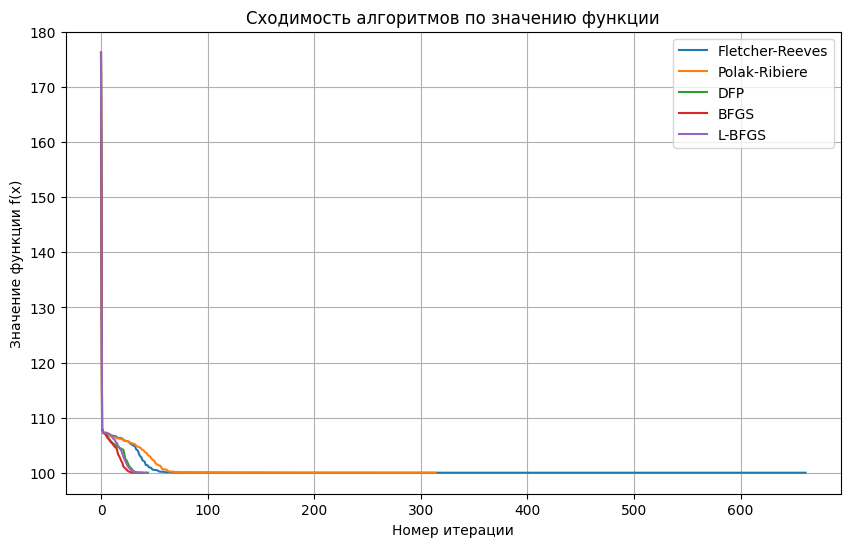

In [ ]:
# Построение графика изменения значения функции по итерациям

plt.figure(figsize=(10, 6))

for result in results:
    plt.plot(result["history"]["f"], label=result["method"])

plt.xlabel("Номер итерации")
plt.ylabel("Значение функции f(x)")
plt.title("Сходимость алгоритмов по значению функции")
plt.legend()
plt.grid(True)
plt.show()

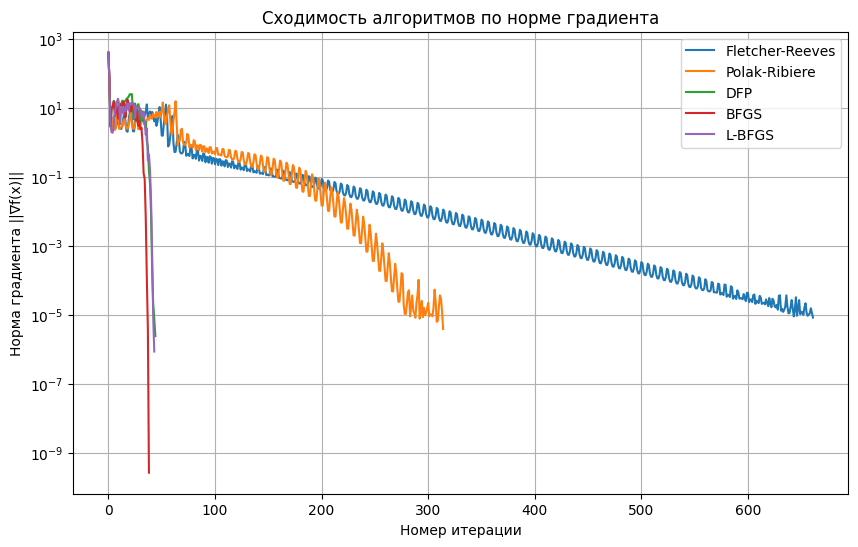

In [ ]:
# Построение графика изменения нормы градиента по итерациям

plt.figure(figsize=(10, 6))

for result in results:
    plt.semilogy(result["history"]["grad_norm"], label=result["method"])

plt.xlabel("Номер итерации")
plt.ylabel("Норма градиента ||∇f(x)||")
plt.title("Сходимость алгоритмов по норме градиента")
plt.legend()
plt.grid(True)
plt.show()

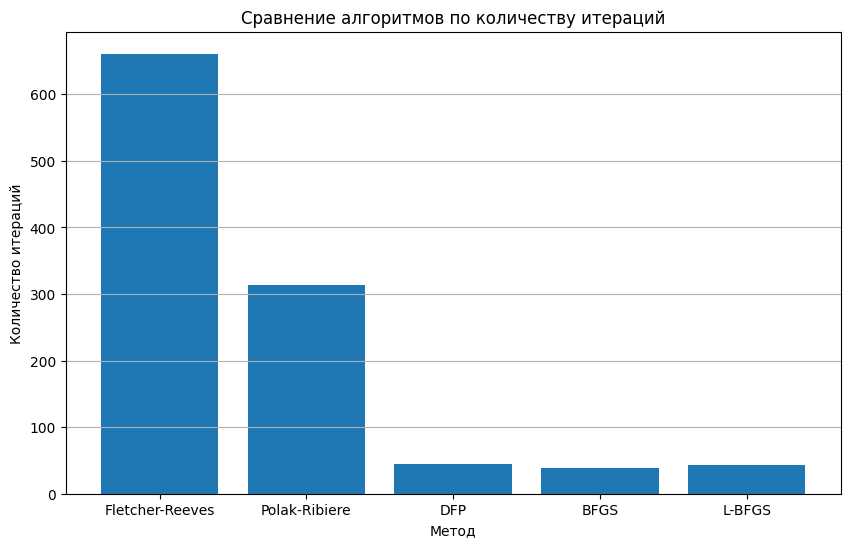

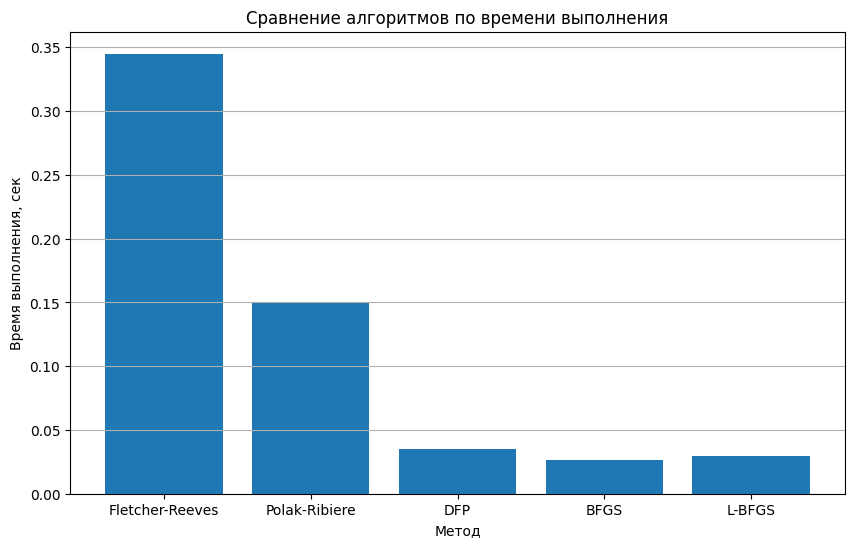

In [ ]:
# Построение диаграмм сравнения количества итераций и времени выполнения

plt.figure(figsize=(10, 6))
plt.bar(comparison_table["Метод"], comparison_table["Количество итераций"])
plt.xlabel("Метод")
plt.ylabel("Количество итераций")
plt.title("Сравнение алгоритмов по количеству итераций")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(comparison_table["Метод"], comparison_table["Время выполнения, сек"])
plt.xlabel("Метод")
plt.ylabel("Время выполнения, сек")
plt.title("Сравнение алгоритмов по времени выполнения")
plt.grid(axis="y")
plt.show()